## Решение краевой задачи

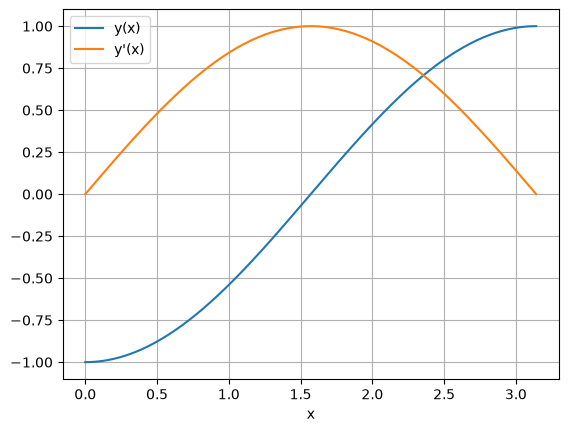

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# начальная сетка
x = np.linspace(0, np.pi, 5)

# начальное приближение
y = np.vstack((-1 + 2 / np.pi * x, np.zeros_like(x)))

# функция правых частей
def f(x, y):
    return np.vstack((y[1], -y[0]))

# функция граничных условий
def bc(ya, yb):
    return np.array([ya[0] + 1, yb[0] - 1])

# решение краевой задачи
sol = solve_bvp(f, bc, x, y)

# сетка для гладкой отрисовки
x_plot = np.linspace(0, np.pi, 200)
y_plot = sol.sol(x_plot)

# построение графиков
plt.figure()
plt.plot(x_plot, y_plot[0], label="y(x)")
plt.plot(x_plot, y_plot[1], label="y'(x)")
plt.xlabel("x")
plt.grid(True)
plt.legend()
plt.savefig('fig-solve_bvp.png')
plt.show()

## Пример из MATLAB-курса: проверка краевой задачи решением задачи Коши (`29_test_bvp.m`)

Краевая задача $y'' = -y$, $y(0) = -1$, $y(4) = 1$ решается по грубому начальному приближению на трёх узлах. Затем из найденных $y(0)$, $y'(0)$ решается задача Коши, и оба решения сравниваются. Такая проверка требуется в задачах З2.19–24 сборника.

Точное решение: $y = -\cos x + C\sin x$, $C = (1 + \cos 4)/\sin 4$.

The algorithm converged to the desired accuracy. | узлов в итоговой сетке: 9
ошибка solve_bvp: 0.0002846582722519919
ошибка задачи Коши: 0.0006934076650439436 | y(4) = 0.999342890309679


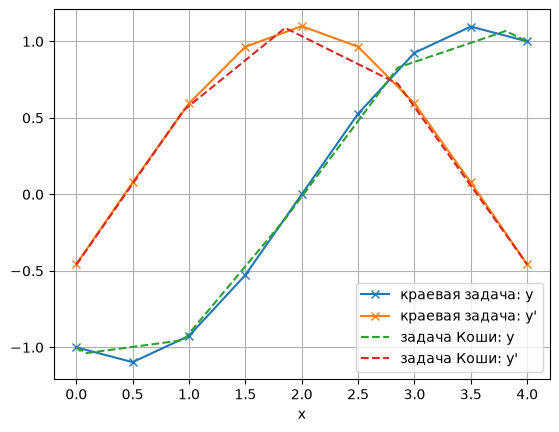

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, solve_ivp

a, b = 0.0, 4.0


def f(x, u):
    return np.vstack((u[1], -u[0]))


def bc(ua, ub):
    return np.array([ua[0] + 1, ub[0] - 1])


# грубое начальное приближение: 3 узла, y -- прямая от -1 до 1, y' = 0
x0 = np.linspace(a, b, 3)
u0 = np.vstack((np.linspace(-1, 1, 3), np.zeros(3)))
sol = solve_bvp(f, bc, x0, u0)
print(sol.message, '| узлов в итоговой сетке:', sol.x.size)

# задача Коши из найденных начальных условий (аналог ode45 в MATLAB)
ivp = solve_ivp(lambda t, u: [u[1], -u[0]], (a, b), sol.y[:, 0], dense_output=True)

C = (1 + np.cos(4)) / np.sin(4)
exact = lambda x: -np.cos(x) + C * np.sin(x)
xx = np.linspace(a, b, 200)
print('ошибка solve_bvp:', np.abs(sol.sol(xx)[0] - exact(xx)).max())
print('ошибка задачи Коши:', np.abs(ivp.sol(xx)[0] - exact(xx)).max(),
      '| y(4) =', ivp.y[0, -1])

plt.plot(sol.x, sol.y[0], 'x-', label='краевая задача: y')
plt.plot(sol.x, sol.y[1], 'x-', label="краевая задача: y'")
plt.plot(ivp.t, ivp.y[0], '--', label='задача Коши: y')
plt.plot(ivp.t, ivp.y[1], '--', label="задача Коши: y'")
plt.xlabel('x')
plt.legend()
plt.grid(True)
plt.show()

Задача Коши воспроизводит решение, но попадает в правое граничное условие $y(4) = 1$ лишь с точностью около $10^{-3}$. Причина — погрешность найденного $y'(0)$: краевая задача решена с точностью по умолчанию (`tol=1e-3`). Повторим расчёт с большей точностью обеих задач.

In [3]:
sol_t = solve_bvp(f, bc, x0, u0, tol=1e-8)
ivp_t = solve_ivp(lambda t, u: [u[1], -u[0]], (a, b), sol_t.y[:, 0],
                  dense_output=True, rtol=1e-10, atol=1e-12)
print('узлов:', sol_t.x.size)
print('ошибка solve_bvp:', np.abs(sol_t.sol(xx)[0] - exact(xx)).max())
print('ошибка задачи Коши:', np.abs(ivp_t.sol(xx)[0] - exact(xx)).max(),
      '| y(4) =', ivp_t.y[0, -1])

узлов: 403
ошибка solve_bvp: 9.90996174010661e-11
ошибка задачи Коши: 9.460943140027211e-11 | y(4) = 0.9999999999092496
